In [31]:
# Analyze sentiment from customer reviews using NLP. 
import pandas as pd 
import numpy as np
from textblob import TextBlob
import matplotlib.pyplot as plt

In [32]:
# Load Dataset
df = pd.read_excel(r"C:\Users\Harshini Ravi\OneDrive\Desktop\Harshini DA\Excel\customer survey data.xlsx") 
print(df.head(2))

  Customer_ID          Name   Age  Gender     City  Satisfaction_Score  \
0        C001    Ravi Kumar  28.0    Male  Chennai                 4.0   
1        C002  Priya Sharma  32.0  Female   Mumbai                 5.0   

            Feedback  Purchase_Amount Survey_Date Preferred_Channel  
0       Good service           2500.0  2025-01-05             Email  
1  Excellent support           4200.0  2025-01-06      Social Media  


In [33]:
df.isna().sum()

Customer_ID           0
Name                  1
Age                   2
Gender                0
City                  0
Satisfaction_Score    2
Feedback              1
Purchase_Amount       1
Survey_Date           1
Preferred_Channel     0
dtype: int64

In [34]:
df['Feedback'] = df['Feedback'].fillna('')
df['Satisfaction_Score'] = df['Satisfaction_Score'].fillna('')
df['Name'] = df['Name'].fillna('')
df['Age'] = df['Age'].fillna('')
df['Purchase_Amount'] = df['Purchase_Amount'].fillna('')
df['Survey_Date'] = df['Survey_Date'].fillna('')

In [ ]:
# Function to classify sentiment

def get_sentiment(text):
    text = str(text)

    polarity = TextBlob(text).sentiment.polarity

    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

# Apply sentiment analysis
df['Sentiment'] = df['Feedback'].apply(get_sentiment)
print(df.head())

  Customer_ID          Name   Age  Gender       City Satisfaction_Score  \
0        C001    Ravi Kumar  28.0    Male    Chennai                4.0   
1        C002  Priya Sharma  32.0  Female     Mumbai                5.0   
2        C003   Arjun Singh          Male      Delhi                3.0   
3        C004    Sneha Iyer  26.0  Female  Bangalore                4.0   
4        C005   Vikram Shah  40.0    Male  Ahmedabad                      

             Feedback Purchase_Amount Survey_Date Preferred_Channel Sentiment  
0        Good service          2500.0  2025-01-05             Email  Positive  
1   Excellent support          4200.0  2025-01-06      Social Media  Positive  
2  Average experience          1800.0  2025-01-07               SMS  Negative  
3       Fast delivery          3500.0  2025-01-08             Email  Positive  
4    Delayed response          2200.0  2025-01-09              Call   Neutral  


In [ ]:
# calculate the sentiment score
df['Polarity'] = df['Feedback'].apply(lambda x: TextBlob(x).sentiment.polarity)
print(df[['Feedback', 'Polarity', 'Sentiment']])

                       Feedback  Polarity Sentiment
0                  Good service      0.70  Positive
1             Excellent support      1.00  Positive
2            Average experience     -0.15  Negative
3                 Fast delivery      0.20  Positive
4              Delayed response      0.00   Neutral
5             Loved the product      0.70  Positive
6                Poor packaging     -0.40  Negative
7         Helpful customer care      0.00   Neutral
8                  Good service      0.70  Positive
9   Product quality can improve      0.00   Neutral
10            Excellent quality      1.00  Positive
11                                   0.00   Neutral
12            Very dissatisfied      0.20  Positive
13              Nice experience      0.60  Positive
14            Excellent service      1.00  Positive
15        Support team was slow     -0.30  Negative
16              Okay experience      0.50  Positive
17        User-friendly website      0.00   Neutral
18          

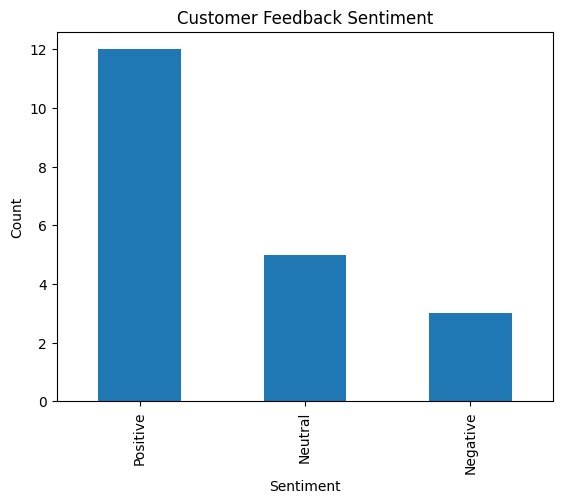

In [ ]:
# Visualization
df['Sentiment'].value_counts().plot(kind='bar')
plt.title("Customer Feedback Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()